<h1>Comparison between Vision Trasnsformer and CNN in transfer learning</h1

Vision transformer model is used for image classification tasks. It serves as an alternative to CNN.

In [ ]:
import torch
import numpy as np
import requests
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import os
from torchvision.datasets import ImageFolder
from torch.utils.tensorboard import SummaryWriter
import torchvision.models
!pip install torchinfo
from torchinfo import summary
from datetime import date
from tqdm.auto import tqdm

In [ ]:
CLASSES = None

<h2>1. Load CIFAR-10 as the dataset

In [ ]:
import tarfile
from pathlib import Path

current_path = Path(".")
#Downloads the data
if not((current_path / "cifar-10-python.tar.gz").is_file()):
  print("Downloading cifar-10 data ...")
  with open("./cifar-10-python.tar.gz", 'wb') as f:
    response = requests.get("https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz")
    f.write(response.content)

#Extracts the data
data_path = Path('data')
with tarfile.open(current_path / "cifar-10-python.tar.gz", "r:gz") as tar:
  if not(data_path.is_dir()):
    print("Extracting cifar-10-python.tar.gz into data directory ...")
    data_path.mkdir()
    tar.extractall(data_path)
    print("Finished extracting, removing the compressed file ...")
    os.remove(current_path / "cifar-10-python.tar.gz")

Extracting cifar-10-python.tar.gz into data directory ...


/tmp/ipykernel_2123/2547599559.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_path)


Finished extracting, removing the compressed file ...


In [ ]:
#unpack the data
import pickle
def unpickle(file):
  with open(file, 'rb') as fo:
    dict = pickle.load(fo, encoding='bytes')
  return dict
data_batch_1 = unpickle("/content/data/cifar-10-batches-py/data_batch_1")

In [ ]:
print(f'Each batch dict contains the following keys: {data_batch_1.keys()}')
print(f'bactch_label: {data_batch_1[b'batch_label']}')
print(f'labels is a list of length {len(data_batch_1[b'labels'])}')
print(f'data is a numpy array of shape {data_batch_1[b'data'].shape}, where each row is an image of 32x32x3')
print(f'filenames is a list of corresponding file names for the images e.g. {data_batch_1[b'filenames'][0]}')

Each batch dict contains the following keys: dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
bactch_label: b'training batch 1 of 5'
labels is a list of length 10000
data is a numpy array of shape (10000, 3072), where each row is an image of 32x32x3
filenames is a list of corresponding file names for the images e.g. b'leptodactylus_pentadactylus_s_000004.png'


<h2>2. Create Torch Dataset and DataLoaders

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
  def __init__(self, data_file_path, metadata_file_path, transform=None, target_transform=None):
    super().__init__()
    self.data_file = data_file_path
    self.data = unpickle(data_file_path)
    self.classes = [x.decode('utf-8') for x in unpickle(metadata_file_path)[b'label_names']] if CLASSES is None else CLASSES #caches the class list
    self.class_to_idx = {name: i for i, name in enumerate(self.classes)}
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.data[b'labels'])

  def __getitem__(self, i):
    target = self.data[b'labels'][i]
    img = self.data[b'data'][i].reshape(3, 32, 32).transpose(1,2,0)
    if self.transform:
      img = self.transform(img)
    if self.target_transform:
      target = self.target_transform(target)
    return img, target

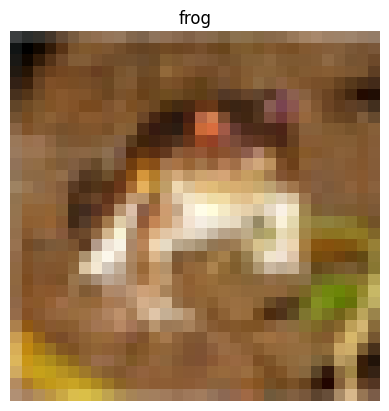

In [ ]:
#Test CustomDataset
dataset_sample = CustomDataset("/content/data/cifar-10-batches-py/data_batch_1", "/content/data/cifar-10-batches-py/batches.meta")
plt.imshow(dataset_sample.__getitem__(0)[0])
plt.title(dataset_sample.classes[dataset_sample.__getitem__(0)[1]])
plt.axis('off')
plt.show()

In [ ]:
def create_dataloaders(transform):
  #concatenate data batch 1 to 5 into a dataset for training
  train_datasets = [CustomDataset(f"/content/data/cifar-10-batches-py/data_batch_{i}", "/content/data/cifar-10-batches-py/batches.meta", transform=transform) for i in range(1, 6)]
  train_dataset = torch.utils.data.ConcatDataset(train_datasets)

  test_dataset = CustomDataset("/content/data/cifar-10-batches-py/test_batch", "/content/data/cifar-10-batches-py/batches.meta", transform=transform)

  #create DataLoader
  train_dataloader = DataLoader(
      dataset=train_dataset,
      batch_size=32,
      shuffle=True,
      num_workers=os.cpu_count()
  )

  test_dataloader = DataLoader(
      dataset=test_dataset,
      batch_size=32,
      shuffle=True,
      num_workers=os.cpu_count()
  )

  return train_dataloader, test_dataloader

In [ ]:
transform = transforms.Compose([
      transforms.ToTensor(),
      torchvision.models.ViT_B_16_Weights.DEFAULT.transforms()
  ])
train_dataloader, test_dataloader = create_dataloaders(transform)

<h2>4. Create a model with ViT as backbone and custom classifier head

In [ ]:
model_0 = torchvision.models.vit_b_16(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 64.7MB/s]


In [ ]:
summary(model_0, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
VisionTransformer                             [32, 3, 224, 224]         [32, 1000]                768                       True
├─Conv2d: 1-1                                 [32, 3, 224, 224]         [32, 768, 14, 14]         590,592                   True
├─Encoder: 1-2                                [32, 197, 768]            [32, 197, 768]            151,296                   True
│    └─Dropout: 2-1                           [32, 197, 768]            [32, 197, 768]            --                        --
│    └─Sequential: 2-2                        [32, 197, 768]            [32, 197, 768]            --                        True
│    │    └─EncoderBlock: 3-1                 [32, 197, 768]            [32, 197, 768]            7,087,872                 True
│    │    └─EncoderBlock: 3-2                 [32, 197, 768]            [32, 197, 768]        

In [ ]:
for name, module in model_0.named_children():
  print(name)

conv_proj
encoder
heads


In [ ]:
#freeze the pretrained model backbone
model_0.requires_grad_(False)
#change the classifier or MLP Head
model_0.heads = torch.nn.Sequential(
    torch.nn.Linear(768, 10, bias=True)
)

In [ ]:
summary(model_0, input_size=(32, 3, 224, 224), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
VisionTransformer                             [32, 3, 224, 224]         [32, 10]                  768                       Partial
├─Conv2d: 1-1                                 [32, 3, 224, 224]         [32, 768, 14, 14]         (590,592)                 False
├─Encoder: 1-2                                [32, 197, 768]            [32, 197, 768]            151,296                   False
│    └─Dropout: 2-1                           [32, 197, 768]            [32, 197, 768]            --                        --
│    └─Sequential: 2-2                        [32, 197, 768]            [32, 197, 768]            --                        False
│    │    └─EncoderBlock: 3-1                 [32, 197, 768]            [32, 197, 768]            (7,087,872)               False
│    │    └─EncoderBlock: 3-2                 [32, 197, 768]            [32, 197, 768] 

<h2>4. Start training

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               current_epoch: int):
    model.train()
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    model.to(device=device)

    # Training Loop
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device,
                                          current_epoch=epoch)
        test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    return results

In [ ]:
results = train(model_0, train_dataloader, test_dataloader, torch.nn.CrossEntropyLoss(), torch.optim.SGD(params=model_0.parameters(), lr=0.0001), 5, torch.device("cuda"))

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.8700 | train_acc: 0.4784 | test_loss: 1.5072 | test_acc: 0.7271
Epoch: 2 | train_loss: 1.2620 | train_acc: 0.8112 | test_loss: 1.0682 | test_acc: 0.8577


<h2>5. Compare it to Resnet

In [ ]:
transform = transforms.Compose([
      transforms.ToTensor(),
      torchvision.models.ResNet18_Weights.DEFAULT.transforms()
  ])
train_dataloader, test_dataloader = create_dataloaders(transform)

model_1 = torchvision.models.resnet18(weights="DEFAULT")


In [ ]:
for name, module in model_1.named_children():
  print(name)

In [ ]:
#freeze the pretrained model backbone
model_1.requires_grad_(False)
#change the classifier or MLP Head
model_1.heads = torch.nn.Sequential(
    torch.nn.Linear(768, 10, bias=True)
)

In [ ]:
results = train(model_1, train_dataloader, test_dataloader, torch.nn.CrossEntropyLoss(), torch.optim.SGD(params=model_0.parameters(), lr=0.0001), 5, torch.device("cuda"))